In [14]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

plt.style.use("seaborn-v0_8")

In [15]:

# Locate all water_calibration.json files
root_dir = "./data"   

json_files = []
for path, dirs, files in os.walk(root_dir):
    for f in files:
        if f == "water_calibration.json":
            json_files.append(os.path.join(path, f))

print(f"Found {len(json_files)} calibration files")



Found 19 calibration files


In [38]:

# Process all calibration files

def load_and_recompute(json_path):
    with open(json_path, "r") as f:
        data = json.load(f)

    measurements = data["input"]["measurements"]

    # Extract valve_open_time and water_weight
    times = []
    weights = []

    for m in measurements:
        times.append(m["valve_open_time"])
        weights.append(m["water_weight"][0])  # list of length 1

    X = np.array(times).reshape(-1, 1)
    y = np.array(weights)

    # Fit linear regression
    model = LinearRegression()
    model.fit(X, y)

    recomputed_slope = model.coef_[0]
    recomputed_intercept = model.intercept_
    recomputed_r2 = model.score(X, y)

    # Extract original values from JSON
    original_slope = data["output"]["slope"]
    original_intercept = data["output"]["offset"]
    original_r2 = data["output"]["r2"]

    df = pd.DataFrame({
        "valve_open_time": times,
        "water_weight": weights
    })

    return {
        "df": df,
        "recomputed_slope": recomputed_slope,
        "recomputed_intercept": recomputed_intercept,
        "recomputed_r2": recomputed_r2,
        "original_slope": original_slope,
        "original_intercept": original_intercept,
        "original_r2": original_r2
    }



results = []

for jf in json_files:
    r = load_and_recompute(jf)
    r["file"] = jf
    results.append(r)

results
# Display comparison of original vs recomputed values
for res in results:
    print(f"File: {res['file']}")
    print(f"            Original | 1/recomp | Recomputed ")    
    print(f" slope:     {res['original_slope']:.5f}  | {1/res['recomputed_slope']:.5f}  |  {res['recomputed_slope']:.2f}")
    print(f" intercept: {res['original_intercept']:.4f}  |          |  {res['recomputed_intercept']:.4f}   ")
    print(f" R²:        {res['original_r2']:.5f}  |          |  {res['recomputed_r2']:.4f}")
    print("-" * 50)


File: ./data\12A_2025-09-07T004326Z\water_calibration.json
            Original | 1/recomp | Recomputed 
 slope:     0.10814  | 0.10833  |  9.23
 intercept: -0.0248  |          |  0.2308   
 R²:        0.99829  |          |  0.9983
--------------------------------------------------
File: ./data\12A_2025-11-05T000234Z\water_calibration.json
            Original | 1/recomp | Recomputed 
 slope:     0.07093  | 0.07099  |  14.09
 intercept: -0.0027  |          |  0.0389   
 R²:        0.99918  |          |  0.9992
--------------------------------------------------
File: ./data\12A_2026-01-31T232630Z\water_calibration.json
            Original | 1/recomp | Recomputed 
 slope:     0.07304  | 0.07311  |  13.68
 intercept: -0.0041  |          |  0.0571   
 R²:        0.99896  |          |  0.9990
--------------------------------------------------
File: ./data\12B_2025-09-06T222618Z\water_calibration.json
            Original | 1/recomp | Recomputed 
 slope:     0.07926  | 0.07949  |  12.58
 in

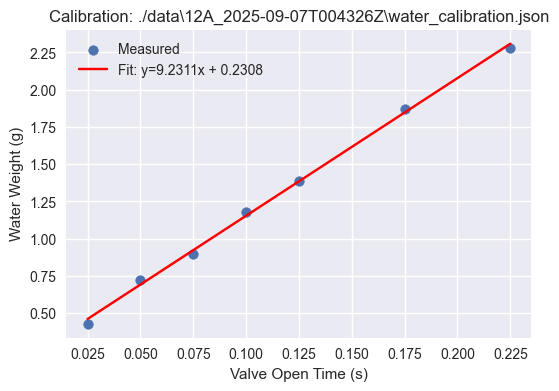

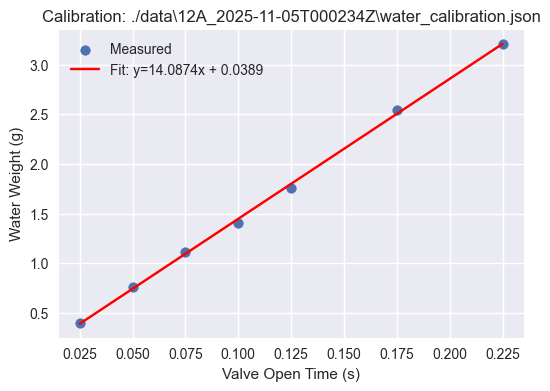

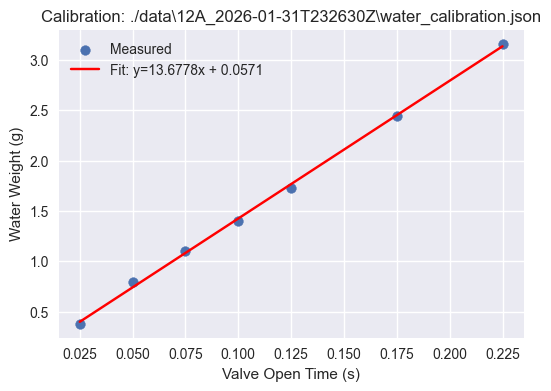

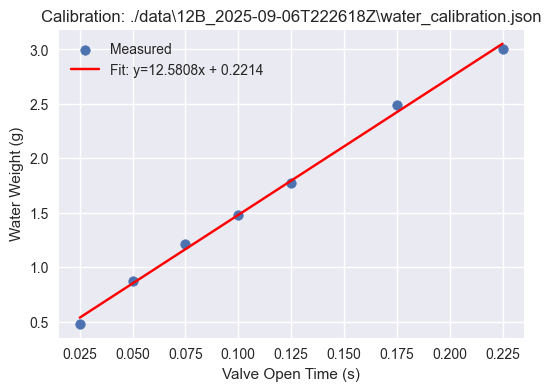

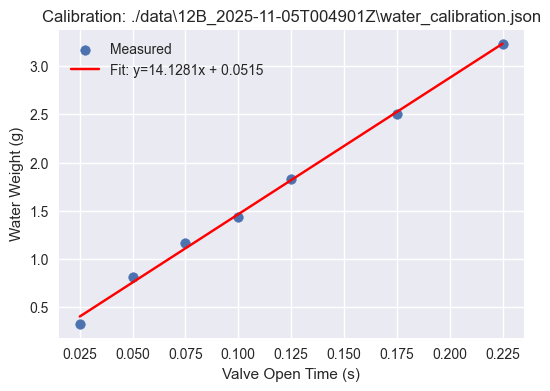

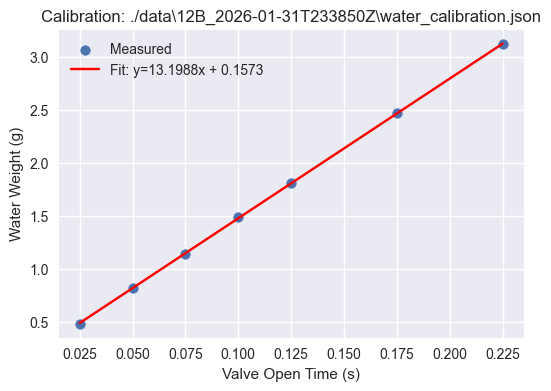

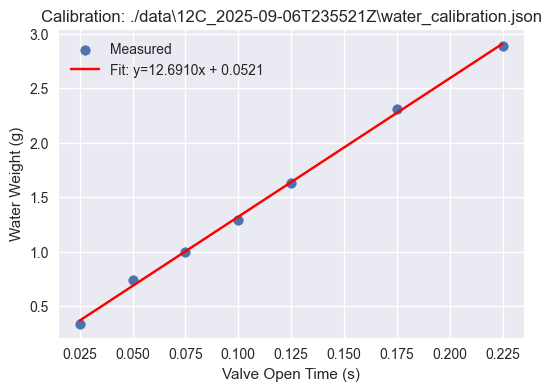

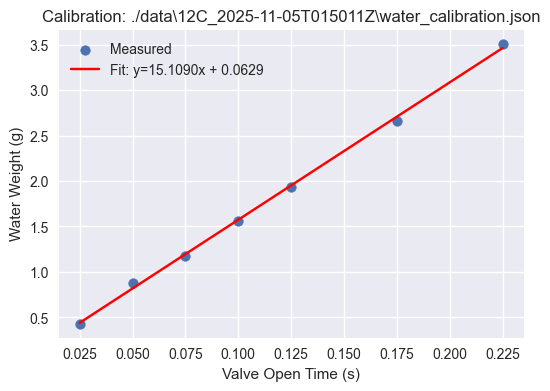

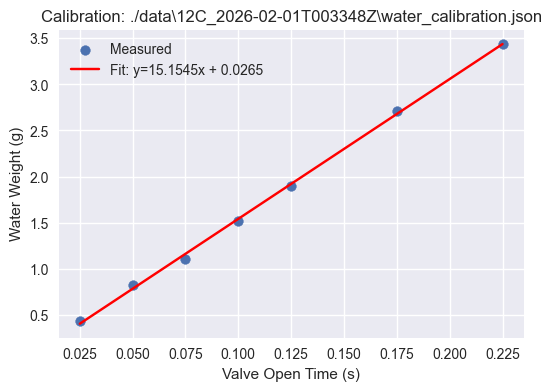

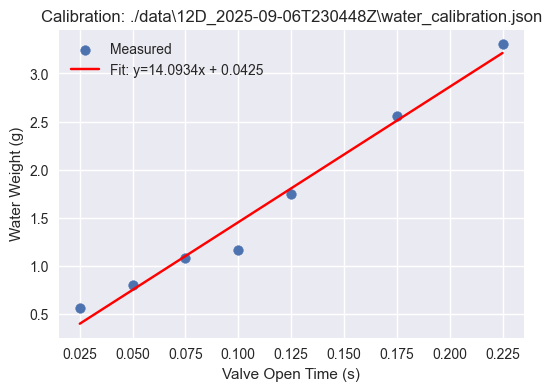

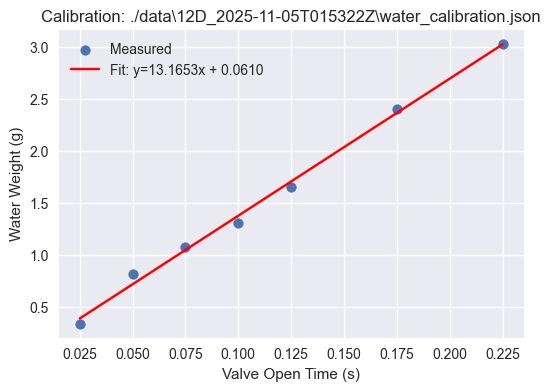

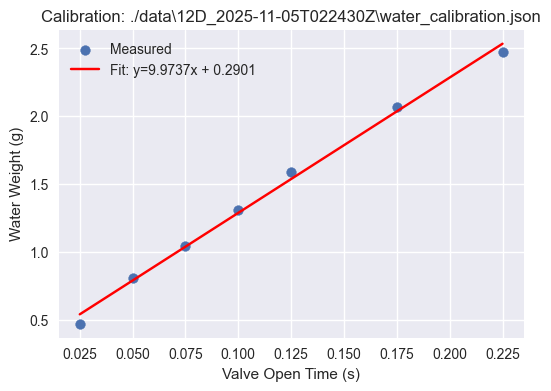

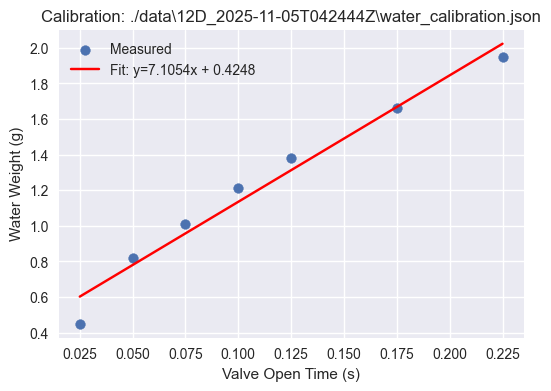

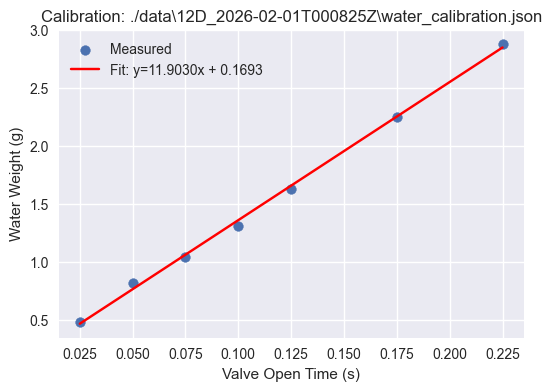

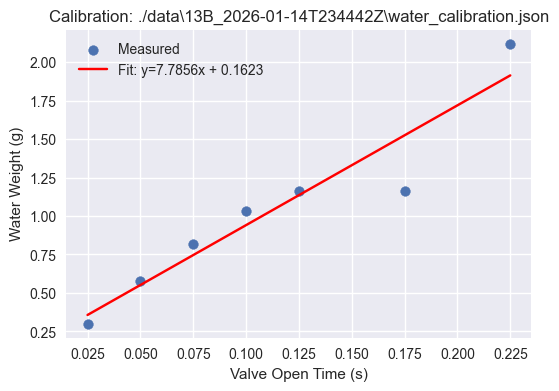

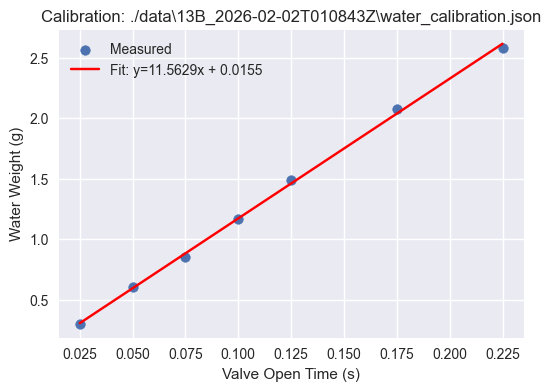

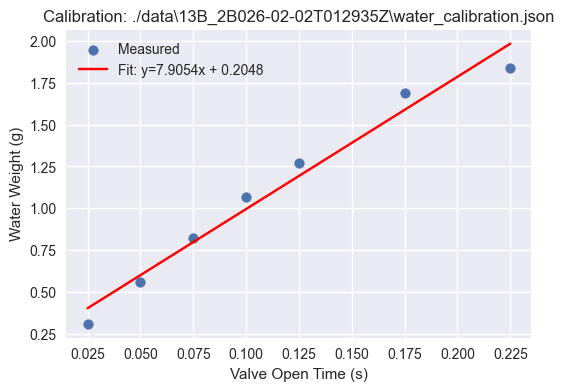

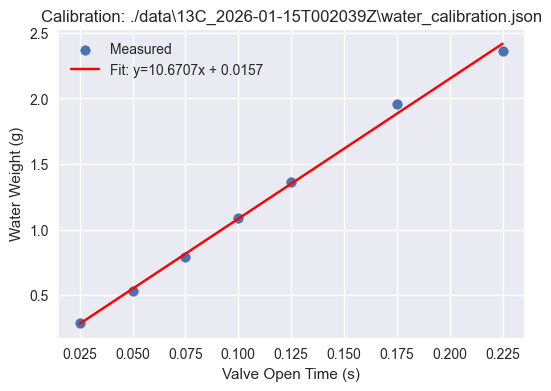

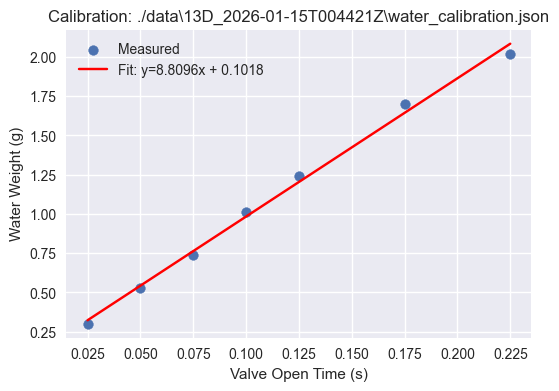

In [17]:
# Plot each calibration curve
for r in results:
    df = r["df"]
    slope = r["recomputed_slope"]
    intercept = r["recomputed_intercept"]

    x = df["valve_open_time"]
    y_pred = slope * x + intercept

    plt.figure(figsize=(6,4))
    plt.scatter(df["valve_open_time"], df["water_weight"], label="Measured")
    plt.plot(x, y_pred, color="red", label=f"Fit: y={slope:.4f}x + {intercept:.4f}")
    plt.title(f"Calibration: {r['file']}")
    plt.xlabel("Valve Open Time (s)")
    plt.ylabel("Water Weight (g)")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:

# Summary plot of slopes across directories

plt.figure(figsize=(8,4))

slopes = [r["slope"] for r in results]
labels = [os.path.basename(os.path.dirname(r["file"])) for r in results]

plt.bar(labels, slopes)
plt.ylabel("Slope (g per second)")
plt.title("Recomputed Slopes Across Calibration Files")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
